# 01 - EDA (Exploratory Data Analysis)
## Malicious URL Detection - Progetto Machine Learning

**Obiettivo di questo notebook**: guardare il subset con attenzione, PRIMA di costruire
qualunque modello, per capire cosa contiene davvero, se e' affidabile, e quali indizi
suggerisce sul problema. Non si addestra ancora nulla in questo notebook.

**Perche' lo facciamo** (da ripetere anche in presentazione):
1. Scovare problemi di qualita' dei dati (valori mancanti, duplicati) prima che rovinino
   feature engineering e training.
2. Verificare che il campionamento stratificato fatto in `make_subset.py` abbia
   davvero mantenuto le proporzioni originali tra le 4 classi.
3. Costruire ipotesi informate su quali feature saranno utili (si veda `src/features.py`),
   controllando se hanno senso guardando esempi reali.
4. Intercettare eventuali etichette sbagliate nel dataset.
5. Avere la prova documentata (grafici + osservazioni) del metodo seguito, da mostrare
   nelle slide finali.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Rende i grafici leggermente piu' grandi e leggibili di default
plt.rcParams["figure.figsize"] = (7, 4)
sns.set_style("whitegrid")

## Caricamento del subset


In [12]:
from pathlib import Path

# Proviamo alcuni percorsi comuni, cosi' il notebook funziona sia in locale
# (aperto dentro notebooks/) sia se lanciato da un'altra posizione.
candidate_paths = [
    Path("../data/subset/malicious_urls_subset.csv"),   # locale, notebook aperto in notebooks/
    Path("data/subset/malicious_urls_subset.csv"),      # locale, aperto dalla root del progetto
    Path("malicious_urls_subset.csv"),                  # Colab, file caricato nella sessione
]

subset_path = next((p for p in candidate_paths if p.exists()), None)
if subset_path is None:
    raise FileNotFoundError(
        "Non trovo il subset in nessuno dei percorsi previsti: "
        f"{[str(p) for p in candidate_paths]}. "
        "Controlla dove hai salvato/caricato il file."
    )

print("Uso il file:", subset_path.resolve())
df = pd.read_csv(subset_path)

Uso il file: C:\Users\Riccardo\Desktop\LM CECAI\1° anno - 2° semestre\3. Machine Learning (Biggio)\Progetto\ML_Project\data\subset\malicious_urls_subset.csv


## Blocco 1 - Controllo strutturale

**Domanda a cui rispondiamo**: i dati sono puliti? Ci sono valori mancanti o righe duplicate
che potrebbero rompere il feature engineering nei prossimi notebook?

In [10]:
print("Righe, colonne:", df.shape)

print("\nTipi di dato per colonna:")
print(df.dtypes)

print("\nValori mancanti per colonna:")
print(df.isna().sum())

print("\nRighe duplicate (stesso url esatto):", df.duplicated(subset=["url"]).sum())

Righe, colonne: (15000, 2)

Tipi di dato per colonna:
url     str
type    str
dtype: object

Valori mancanti per colonna:
url     0
type    0
dtype: int64

Righe duplicate (stesso url esatto): 62


**Nota importante**: `duplicated()` trova solo url IDENTICI carattere per carattere.
Non troverebbe, ad esempio, `unica.it/pagina` e `www.unica.it/pagina` come duplicati (sono
stringhe diverse), anche se probabilmente rappresentano lo stesso sito. Se dopo aver visto
i risultati si sospetta "quasi-duplicati" di questo tipo, e' un'osservazione valida da
riportare in slide, anche senza necessariamente risolverla nel codice.

**Cosa fare se troviamo valori mancanti**: nella cella successiva li rimuoviamo (sono
tipicamente pochissime righe su 15.000, quindi non e' un problema toglierle).

In [13]:
n_prima = len(df)
df = df.dropna(subset=["url", "type"]).reset_index(drop=True)
n_dopo = len(df)
print(f"Righe rimosse per valori mancanti: {n_prima - n_dopo} (da {n_prima} a {n_dopo})")

Righe rimosse per valori mancanti: 0 (da 15000 a 15000)


## Blocco 2 - Distribuzione della classe (target)

**Domanda a cui rispondiamo**: il campionamento stratificato fatto in `make_subset.py`
ha davvero mantenuto le proporzioni originali tra le 4 classi? Le percentuali attese sono
circa: benign 66%, defacement 15%, phishing 14%, malware 5%.

type
benign        9861
defacement    2222
phishing      2168
malware        749
Name: count, dtype: int64

type
benign        65.7 %
defacement    14.8 %
phishing      14.5 %
malware        5.0 %
Name: proportion, dtype: str


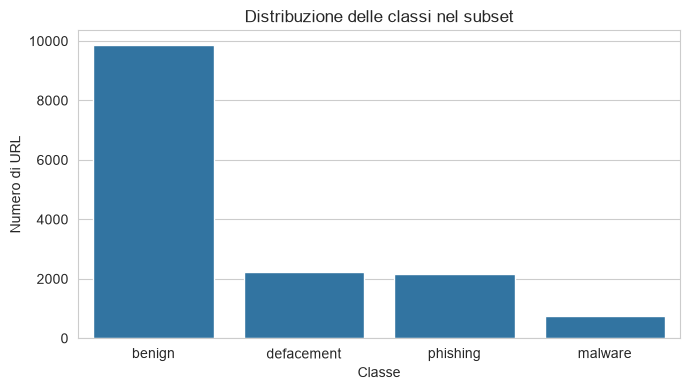

In [5]:
conteggi = df["type"].value_counts()
percentuali = (df["type"].value_counts(normalize=True) * 100).round(1)

print(conteggi)
print()
print(percentuali.astype(str) + " %")

# Grafico a barre della distribuzione delle classi
plt.figure()
sns.countplot(data=df, x="type", order=conteggi.index)
plt.title("Distribuzione delle classi nel subset")
plt.xlabel("Classe")
plt.ylabel("Numero di URL")
plt.tight_layout()
plt.savefig("../figures/distribuzione_classi.png", dpi=150)
plt.show()

## Blocco 3 - Sguardo qualitativo a esempi reali

**Domanda a cui rispondiamo**: le etichette hanno senso? Cosa "sembrano" le classi quando
le leggiamo con i nostri occhi, prima ancora di calcolare qualunque numero?

Qui non si calcola nulla: si legge e basta, per farsi un'idea qualitativa.

In [6]:
for classe in df["type"].unique():
    print(f"\n--- {classe} ({(df['type'] == classe).sum()} esempi nel subset) ---")
    esempi = df[df["type"] == classe]["url"].sample(5, random_state=42).tolist()
    for u in esempi:
        print(" ", u)


--- phishing (2168 esempi nel subset) ---
  http://tharts.net/images/?us.battle.net/login/en/?ref=http://us.battle.net/d3/en/index&app=com-d3
  www-leibniz.imag.fr/PMP/
  toners.ae
  www.talsorian.com/dbzindex.shtml
  frustrated-model.000webhostapp.com

--- benign (9861 esempi nel subset) ---
  laplumedelouise.fr/js-global/8854b147215088431d28f6a8a84b9508/wrp.htm
  paypal.fr.cgi-bin.login58574hg89789.allforhimevents.com/paypal.fr/cgi_bin1/051efacfa6a22f8def2fc30db07302a5/
  http://distractify.com/post/related/id/55521b5f4a0c4b2553d5da5d/skip/50/limit/10/back/0
  bannonmen.com/?p=174
  legalsounds.com/download-mp3/phil-harris_bruce-reitherman/disney-soundtracks-collection/the-bare-necessities/song_3571030

--- defacement (2222 esempi nel subset) ---
  http://www.malin-kh.cz/vae-inzeraty?page=show_category&catid=11&order=0&expand=0
  http://www.divanomoveis.com.br/Produtos/default.asp?opc=6&ops=1
  http://www.arcolec.com/index.php?option=com_mailto&tmpl=component&link=aHR0cDovL3d3dy5hcm

**Cosa annotare qui per la presentazione**: scrivere 2-3 osservazioni qualitative,
ad esempio "gli URL di phishing imitano spesso nomi di brand noti (paypal, amazon...)",
oppure "gli URL di malware puntano spesso a file con estensioni eseguibili". Queste
osservazioni sono la giustificazione "in parole povere" delle feature scelte in
`features.py` (le parole sospette, i nomi di brand, le estensioni eseguibili, ecc. non
sono state scelte a caso, ma proprio a partire da osservazioni come queste).

## Blocco 4 - Prima occhiata numerica: la lunghezza dell'URL per classe

**Domanda a cui rispondiamo**: emergono gia' pattern misurabili, anche prima del feature
engineering vero e proprio?

            mean  min   max
type                       
benign      57.4    7  1078
defacement  85.8   23   305
malware     58.6    9   228
phishing    45.7    2   473


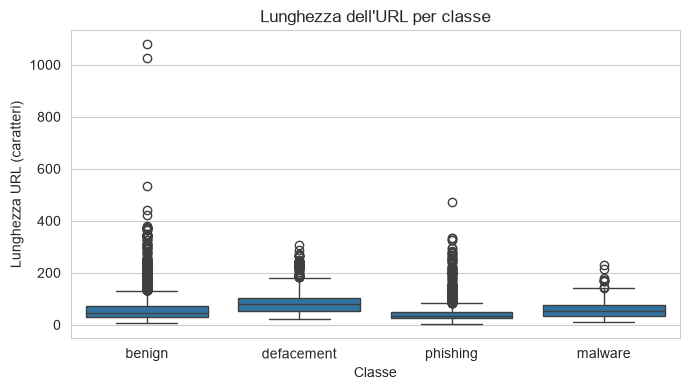

In [7]:
df["url_length"] = df["url"].str.len()

print(df.groupby("type")["url_length"].agg(["mean", "min", "max"]).round(1))

# Boxplot: mostra la distribuzione della lunghezza per ciascuna classe
plt.figure()
sns.boxplot(data=df, x="type", y="url_length", order=conteggi.index)
plt.title("Lunghezza dell'URL per classe")
plt.xlabel("Classe")
plt.ylabel("Lunghezza URL (caratteri)")
plt.tight_layout()
plt.savefig("../figures/lunghezza_url_per_classe.png", dpi=150)
plt.show()

## Conclusioni di questo notebook

Riassumere qui, in poche righe, cosa avete osservato (da riusare quasi parola per parola
in presentazione):

- Il subset ha [N] righe dopo la pulizia, nessun problema strutturale grave / [problemi trovati].
- Le proporzioni tra le classi rispecchiano quelle originali: [si/no, con che percentuali].
- Osservazioni qualitative sulle 4 classi: [...].
- La lunghezza dell'URL sembra gia' un buon segnale distintivo tra classi benigne e
  malevole: [confermare o smentire in base al grafico ottenuto].

**Prossimo passo**: `02_feature_engineering.ipynb` - applicare tutte le 28 feature di
`src/features.py` al subset e verificare, con lo stesso tipo di grafici, quali sono
davvero utili a distinguere le classi.